<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/Week2%263/Week2_Bibit_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 2 — Preprocessing Data Review Bibit**

Notebook ini berisi pipeline lengkap untuk melakukan **text preprocessing** pada data ulasan aplikasi Bibit dari Google Play Store. Pipeline mencakup langkah-langkah berikut:

1. **Setup & Instalasi** — instalasi library dan download resource NLTK
2. **Data Load** — memuat dataset ulasan
3. **Remove Duplicate** — menghapus ulasan yang duplikat
4. **Sentiment Labeling** — memberi label sentimen berdasarkan skor bintang
5. **Lowercasing** — mengubah teks ke huruf kecil
6. **Slang Normalization** — menormalkan kata-kata alay/slang ke bentuk formal
7. **Text Cleaning** — membersihkan URL, emoji, angka, dan karakter khusus
8. **Tokenization** — memecah kalimat menjadi daftar kata
9. **Stopword Removal** — menghapus kata-kata umum yang tidak bermakna
10. **Lemmatization** — mengubah kata ke bentuk dasar
11. **Rare Words Removal** — menghapus kata yang sangat jarang muncul
12. **Validasi & Simpan** — validasi hasil akhir dan ekspor ke CSV

## 1. Setup & Instalasi

Pada tahap ini dilakukan instalasi seluruh library yang dibutuhkan untuk mendukung preprocessing teks Bahasa Indonesia:
- **Sastrawi** — stemmer dan stopword Bahasa Indonesia
- **emoji** — untuk mendeteksi dan menghapus karakter emoji
- **nlp-id** — untuk lemmatization Bahasa Indonesia
- **NLTK** — toolkit NLP umum, digunakan untuk tokenisasi dan stopword

Selain itu, dilakukan konfigurasi awal untuk visualisasi dan peringatan.

In [1]:
# ── Instalasi Library ──────────────────────────────────────────────
!pip install Sastrawi -q
!pip install emoji -q
!pip install nlp-id -q

# ── NLTK Resource ─────────────────────────────────────────────────
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# ── Import Library ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import urllib.request
import emoji
from collections import Counter

from nltk.tokenize import word_tokenize
from nltk.corpus   import stopwords

from nlp_id.lemmatizer import Lemmatizer
from nlp_id.stopword   import StopWord

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import warnings
warnings.filterwarnings('ignore')

# ── Konfigurasi Visualisasi ────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('✅ Setup selesai.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 18.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.34.4 which is incompatible.
✅ Setup selesai.


## 2. Data Load

Dataset dimuat dari Google Drive. Data berisi ulasan pengguna aplikasi Bibit yang diambil dari Google Play Store, meliputi kolom seperti `content` (isi ulasan), `score` (bintang 1–5), `at` (tanggal ulasan), dan lainnya.

> **Catatan:** Pastikan file `bibit_review.csv` sudah tersedia di path Google Drive yang ditentukan sebelum menjalankan sel ini.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df_review = pd.read_csv('/content/drive/MyDrive/NLP/bibit_review.csv')

print(f'Shape   : {df_review.shape[0]:,} baris x {df_review.shape[1]} kolom')
print(f'Kolom   : {list(df_review.columns)}')
df_review.head()

Mounted at /content/drive
Shape   : 49,109 baris x 11 kolom
Kolom   : ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7e7dafb4-4bdb-47a5-a913-df0b6552231d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,KECEWA sudah nggk bisa pencairan instan (sesam...,1,0,3.107.0,2026-04-05 07:00:34,"Hai kak, terkait hal tersebut terdapat update ...",2026-04-05 20:38:22,3.107.0
1,71dbb877-abe4-4977-9321-aacbc2c9a2a1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bermanfaat buat menabung,5,0,3.107.0,2026-04-05 03:26:06,Terima kasih Kak Denny telah menjadi pengguna ...,2026-04-05 13:38:53,3.107.0
2,0dcb19fc-efb7-4da7-83e3-0aa09927ff08,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya sangat suka dimana bibit menjadi aplikasi...,4,0,3.106.2,2026-04-04 22:06:56,"Hai Kak Rizky, kami mohon maaf atas ketidaknya...",2026-04-05 13:38:32,3.106.2
3,80812a23-73e0-4633-811f-bdcba99a0db3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa sekarang jatah Pencairan instan dibatas...,2,0,3.106.2,2026-04-04 13:47:36,Hai Kak Henry. Saat ini terdapat perubahan S &...,2026-04-05 13:36:37,3.106.2
4,e9545ada-5741-4afb-b846-6c3c52aba31b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Gajelas, penambahn rekening baru gua ditolak, ...",1,0,3.107.0,2026-04-04 13:10:08,"Hai Kak Rapli, ketika tambah rekening, pastika...",2026-04-05 13:28:42,3.107.0


## 3. Remove Duplicate

Ulasan yang memiliki isi (`content`) identik dihapus karena dapat menyebabkan bias pada analisis. Proses ini mempertahankan kemunculan pertama dari setiap ulasan unik dan membuang sisanya.

In [3]:
rows_before = len(df_review)
df_review   = df_review.drop_duplicates(subset='content', keep='first')

print(f'Duplikat dihapus : {rows_before - len(df_review):,}')
print(f'Sisa baris       : {len(df_review):,}')
df_review.head(3)

Duplikat dihapus : 11,300
Sisa baris       : 37,809


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7e7dafb4-4bdb-47a5-a913-df0b6552231d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,KECEWA sudah nggk bisa pencairan instan (sesam...,1,0,3.107.0,2026-04-05 07:00:34,"Hai kak, terkait hal tersebut terdapat update ...",2026-04-05 20:38:22,3.107.0
1,71dbb877-abe4-4977-9321-aacbc2c9a2a1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bermanfaat buat menabung,5,0,3.107.0,2026-04-05 03:26:06,Terima kasih Kak Denny telah menjadi pengguna ...,2026-04-05 13:38:53,3.107.0
2,0dcb19fc-efb7-4da7-83e3-0aa09927ff08,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya sangat suka dimana bibit menjadi aplikasi...,4,0,3.106.2,2026-04-04 22:06:56,"Hai Kak Rizky, kami mohon maaf atas ketidaknya...",2026-04-05 13:38:32,3.106.2


## 4. Sentiment Labeling

Label sentimen dibuat berdasarkan kolom `score` (rating bintang 1–5):
- **Negatif** → skor 1–2
- **Netral**  → skor 3
- **Positif** → skor 4–5

Label ini nantinya digunakan sebagai *ground-truth* untuk tugas klasifikasi sentimen.

In [4]:
def label_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df_review['sentiment'] = df_review['score'].apply(label_sentiment)

print('Distribusi Label Sentimen:')
print(df_review['sentiment'].value_counts())
print()
print('Distribusi (%):')
print((df_review['sentiment'].value_counts(normalize=True) * 100).round(2))

Distribusi Label Sentimen:
sentiment
positive    28419
negative     7116
neutral      2274
Name: count, dtype: int64

Distribusi (%):
sentiment
positive    75.16
negative    18.82
neutral      6.01
Name: proportion, dtype: float64


## 5. Lowercasing

Seluruh teks diubah menjadi huruf kecil (*lowercase*) agar pemrosesan selanjutnya bersifat *case-insensitive*. Misalnya, kata "Bagus" dan "bagus" akan diperlakukan sebagai token yang sama.

In [5]:
df_review['cleaned'] = df_review['content'].astype(str).str.lower()

df_review[['content', 'cleaned']].head(3)

,content,cleaned
0,KECEWA sudah nggk bisa pencairan instan (sesam...,kecewa sudah nggk bisa pencairan instan (sesam...
1,sangat bermanfaat buat menabung,sangat bermanfaat buat menabung
2,saya sangat suka dimana bibit menjadi aplikasi...,saya sangat suka dimana bibit menjadi aplikasi...


## 6. Slang / Alay Normalization

### 6a. Muat Kamus Slang

Kamus alay diunduh dari repositori publik **kamus-alay** (Nasalsabila, GitHub). Kamus ini berisi pemetaan kata-kata tidak baku (slang, singkatan, typo umum) ke bentuk formalnya. Jika pengunduhan gagal, digunakan kamus fallback manual yang mencakup kata-kata alay paling umum.

In [6]:
URL_KAMUS_ALAY = 'https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv'

try:
    path_file, _ = urllib.request.urlretrieve(URL_KAMUS_ALAY, 'slang_indonesia.csv')
    df_slang  = pd.read_csv(path_file)
    slang_map = dict(zip(df_slang['slang'].str.lower(), df_slang['formal'].str.lower()))

    print(f'✅ Kamus alay dimuat: {len(slang_map):,} entri')
    print('Contoh isi kamus:')
    for slang, formal in list(slang_map.items())[:8]:
        print(f'  {slang:<14} => {formal}')

except Exception as err:
    print(f'⚠️  Gagal mengunduh ({err}), menggunakan kamus manual.')
    slang_map = {
        'yg': 'yang',  'gk': 'tidak', 'gak': 'tidak', 'nggak': 'tidak',
        'udah': 'sudah','udh': 'sudah','sdh': 'sudah', 'blm': 'belum',
        'tp': 'tapi',  'jg': 'juga',  'aja': 'saja',  'kyk': 'kayak',
        'utk': 'untuk','dgn': 'dengan','krn': 'karena','bgt': 'banget',
        'gw': 'saya',  'sy': 'saya',  'lu': 'kamu',  'lo': 'kamu',
        'apk': 'aplikasi','apps': 'aplikasi','ga': 'tidak'
    }
    print(f'✅ Kamus fallback siap: {len(slang_map)} entri')

✅ Kamus alay dimuat: 4,331 entri
Contoh isi kamus:
  woww           => wow
  aminn          => amin
  met            => selamat
  netaas         => menetas
  keberpa        => keberapa
  eeeehhhh       => eh
  kata2nyaaa     => kata-katanya
  hallo          => halo


### 6b. Terapkan Normalisasi Slang

Setiap kata dalam ulasan dicek terhadap kamus slang. Jika ditemukan kecocokan, kata tersebut diganti dengan bentuk formalnya. Proses ini dilakukan per-kata (*word-level*) menggunakan `.split()`.

In [7]:
def fix_slang(text):
    words = str(text).split()
    return ' '.join([slang_map.get(w, w) for w in words])

df_review['cleaned'] = df_review['cleaned'].apply(fix_slang)

# Hitung berapa baris yang berubah
is_changed    = df_review['content'].astype(str).str.lower() != df_review['cleaned']
total_changed = is_changed.sum()

print(f'Total baris yang berubah setelah normalisasi: {total_changed:,}')
df_review[is_changed][['content', 'cleaned']].head(5)

Total baris yang berubah setelah normalisasi: 17,310


,content,cleaned
0,KECEWA sudah nggk bisa pencairan instan (sesam...,kecewa sudah enggak bisa pencairan instan (ses...
2,saya sangat suka dimana bibit menjadi aplikasi...,saya sangat suka dimana bibit menjadi aplikasi...
4,"Gajelas, penambahn rekening baru gua ditolak, ...","gajelas, penambahn rekening baru gua ditolak, ..."
5,afk yg sangat bagus dan aman. terpercaya 💯🔥,afk yang sangat bagus dan aman. terpercaya 💯🔥
8,User friendly. Semoga semakin lbh baik dan dip...,user friendly. semoga semakin lebih baik dan d...


## 7. Text Cleaning

Pada tahap ini dilakukan pembersihan teks dari noise yang tidak membawa informasi linguistik:
- **URL** (http/https) → dihapus
- **Alamat email** → dihapus
- **Emoji** → dihapus
- **Angka** → dihapus
- **Karakter non-alfanumerik** (tanda baca, simbol) → dihapus
- **Spasi ganda/ekstra** → dinormalisasi menjadi satu spasi

In [8]:
def clean_text(txt):
    txt = re.sub(r'https?://\S+|www\.\S+', '', str(txt))           # hapus URL
    txt = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', txt)  # hapus email
    txt = emoji.replace_emoji(txt, replace='')                      # hapus emoji
    txt = re.sub(r'\d+', '', txt)                                   # hapus angka
    txt = re.sub(r'[^\w\s]', '', txt)                              # hapus tanda baca
    txt = re.sub(r'\s+', ' ', txt).strip()                         # normalisasi spasi
    return txt

df_review['cleaned'] = df_review['cleaned'].apply(clean_text)

df_review[['content', 'cleaned']].sample(5, random_state=42)

,content,cleaned
4064,puas berkeringat,puas berkeringat
26447,Semua penjelasannya mudah dimengerti Seneng ba...,semua penjelasannya mudah dimengerti senang ba...
20800,Mulai,mulai
23221,Pakai code ini dapetin bonus tambahan eufpzv2,pakai code ini mendapatkan bonus tambahan eufpzv
1739,kurang paham,kurang paham


## 8. Tokenization

Tokenisasi adalah proses memecah string teks menjadi daftar token (kata). Di sini digunakan `word_tokenize` dari NLTK yang mendukung tanda baca dan struktur kalimat Bahasa Indonesia dengan baik. Kolom `token_count` ditambahkan untuk memudahkan analisis panjang ulasan.

In [9]:
df_review['tokens']      = df_review['cleaned'].apply(word_tokenize)
df_review['token_count'] = df_review['tokens'].apply(len)

total_tokens = df_review['token_count'].sum()
avg_tokens   = df_review['token_count'].mean()

print(f'Total token        : {total_tokens:,}')
print(f'Rata-rata per ulasan: {avg_tokens:.2f} token')

df_review[['cleaned', 'tokens', 'token_count']].head(5)

Total token        : 453,544
Rata-rata per ulasan: 12.00 token


,cleaned,tokens,token_count
0,kecewa sudah enggak bisa pencairan instan sesa...,"[kecewa, sudah, enggak, bisa, pencairan, insta...",33
1,sangat bermanfaat buat menabung,"[sangat, bermanfaat, buat, menabung]",4
2,saya sangat suka dimana bibit menjadi aplikasi...,"[saya, sangat, suka, dimana, bibit, menjadi, a...",34
3,kenapa sekarang jatah pencairan instan dibatas...,"[kenapa, sekarang, jatah, pencairan, instan, d...",13
4,gajelas penambahn rekening baru gua ditolak su...,"[gajelas, penambahn, rekening, baru, gua, dito...",11


## 9. Stopword Removal

### 9a. Bangun Daftar Stopword

Stopword adalah kata-kata umum yang frekuensinya tinggi namun tidak membawa makna analitik (misalnya: "yang", "di", "dan"). Daftar stopword digabungkan dari tiga sumber:
1. **NLTK** — stopword Bahasa Indonesia umum (~757 kata)
2. **Sastrawi** — stopword Bahasa Indonesia dari library NLP lokal (~123 kata)
3. **Konteks Bibit** — kata-kata yang memang umum di domain ini tetapi tidak memberi nilai analitik (misalnya: "bibit", "aplikasi", "admin")

Kombinasi ketiga sumber memastikan cakupan stopword yang lebih komprehensif.

In [10]:
# Sumber 1: NLTK
try:
    list_nltk = set(stopwords.words('indonesian'))
    print(f'NLTK (ID) : {len(list_nltk):,} kata')
except:
    list_nltk = set()
    print('NLTK source tidak ditemukan.')

# Sumber 2: Sastrawi
list_sastrawi = set(StopWordRemoverFactory().get_stop_words())
print(f'Sastrawi  : {len(list_sastrawi):,} kata')

# Sumber 3: Kata konteks domain Bibit
bibit_context_words = {
    'bibit', 'investasi', 'reksadana',
    'aplikasi', 'app', 'nya', 'apk', 'sih',
    'deh', 'loh', 'nih', 'lah', 'kok',
    'yah', 'wah', 'tuh', 'gitu', 'gini',
    'kak', 'admin', 'cs'
}

# Gabungkan
stopword_final = list_nltk.union(list_sastrawi).union(bibit_context_words)

print(f'Konteks Bibit: {len(bibit_context_words):,} kata')
print(f'Total gabungan: {len(stopword_final):,} kata')

NLTK (ID) : 757 kata
Sastrawi  : 123 kata
Konteks Bibit: 21 kata
Total gabungan: 792 kata


### 9b. Terapkan Stopword Removal

Setiap token yang terdapat dalam daftar stopword dihapus dari list token. Token dengan panjang ≤ 1 karakter juga ikut dibuang karena tidak membawa makna.

In [11]:
def filter_stopwords(token_list):
    return [word for word in token_list
            if word not in stopword_final and len(word) > 1]

df_review['tokens_no_sw'] = df_review['tokens'].apply(filter_stopwords)

total_before = df_review['tokens'].apply(len).sum()
total_after  = df_review['tokens_no_sw'].apply(len).sum()
diff         = total_before - total_after
pct_diff     = (diff / total_before) * 100

print(f'Token awal  : {total_before:,}')
print(f'Token akhir : {total_after:,}')
print(f'Token hapus : {diff:,} ({pct_diff:.1f}%)')

df_review[['tokens', 'tokens_no_sw']].head(5)

Token awal  : 453,544
Token akhir : 227,560
Token hapus : 225,984 (49.8%)


,tokens,tokens_no_sw
0,"[kecewa, sudah, enggak, bisa, pencairan, insta...","[kecewa, pencairan, instan, bank, menunggu, tu..."
1,"[sangat, bermanfaat, buat, menabung]","[bermanfaat, menabung]"
2,"[saya, sangat, suka, dimana, bibit, menjadi, a...","[suka, cocok, pemula, kasih, bintang, error, d..."
3,"[kenapa, sekarang, jatah, pencairan, instan, d...","[jatah, pencairan, instan, dibatasi, pencairan..."
4,"[gajelas, penambahn, rekening, baru, gua, dito...","[gajelas, penambahn, rekening, gua, ditolak, s..."


## 10. Lemmatization

Lemmatization mengubah setiap kata ke bentuk dasarnya (*lemma*) dengan mempertimbangkan konteks morfologis. Berbeda dengan stemming, lemmatization menghasilkan kata yang tetap valid secara linguistik.

Contoh:
- `berinvestasi` → `investasi`
- `menabung` → `tabung`
- `pendaftaran` → `daftar`

### 10a. Validasi Lemmatizer

In [12]:
base_lemmatizer = Lemmatizer()

sample_words = ['berinvestasi', 'keuangan', 'terpercaya', 'menabung', 'pendaftaran']

print('Validasi Lemmatization:')
for word in sample_words:
    root_word = base_lemmatizer.lemmatize(word)
    print(f'  {word:<15} => {root_word}')

Validasi Lemmatization:
  berinvestasi    => investasi
  keuangan        => uang
  terpercaya      => terpercaya
  menabung        => tabung
  pendaftaran     => daftar


### 10b. Terapkan Lemmatization ke Seluruh Data

Lemmatizer dijalankan pada level kalimat (token-list digabung dahulu menjadi string) karena library `nlp-id` bekerja lebih baik dengan konteks kalimat penuh.

In [13]:
def apply_lemmatization(token_list):
    if not token_list:
        return []
    sentence   = ' '.join(token_list)
    lemmatized = base_lemmatizer.lemmatize(sentence)
    return lemmatized.split()

df_review['tokens_lemma'] = df_review['tokens_no_sw'].apply(apply_lemmatization)

# Hitung berapa token yang berubah
all_before        = [w for sub in df_review['tokens_no_sw']  for w in sub]
all_after         = [w for sub in df_review['tokens_lemma']   for w in sub]
total_lemmatized  = sum(1 for a, b in zip(all_before, all_after) if a != b)

print(f'Token berubah setelah lemmatization: {total_lemmatized:,}')

df_review[['tokens_no_sw', 'tokens_lemma']].head(5)

Token berubah setelah lemmatization: 217,022


,tokens_no_sw,tokens_lemma
0,"[kecewa, pencairan, instan, bank, menunggu, tu...","[kecewa, cair, instan, bank, tunggu, tuju, ban..."
1,"[bermanfaat, menabung]","[manfaat, tabung]"
2,"[suka, cocok, pemula, kasih, bintang, error, d...","[suka, cocok, mula, kasih, bintang, error, buk..."
3,"[jatah, pencairan, instan, dibatasi, pencairan...","[jatah, cair, instan, batas, cair, instan, puas]"
4,"[gajelas, penambahn, rekening, gua, ditolak, s...","[gajelas, penambahn, rekening, gua, tolak, sal..."


## 11. Rare Words Removal

Kata-kata yang muncul sangat jarang (frekuensi ≤ threshold) cenderung merupakan typo, nama khusus, atau noise. Menghapus kata-kata ini membantu mengurangi kebisingan dalam kosakata (*vocabulary*) dan mempercepat pelatihan model.

Di sini digunakan threshold minimum = 2, artinya kata yang hanya muncul 1–2 kali di seluruh corpus akan dihapus.

In [14]:
THRESHOLD_MIN = 2

# Hitung frekuensi seluruh kata (post-lemmatization)
semua_kata      = [kata for sub in df_review['tokens_lemma'] for kata in sub]
freq_counter    = Counter(semua_kata)

kata_langka     = {k for k, v in freq_counter.items() if v <= THRESHOLD_MIN}

total_unik   = len(freq_counter)
total_langka = len(kata_langka)
persen_langka = (total_langka / total_unik) * 100

print(f'Kosakata unik (lemma)            : {total_unik:,}')
print(f'Kata langka (frekuensi ≤ {THRESHOLD_MIN})    : {total_langka:,} ({persen_langka:.1f}%)')
print(f'Contoh kata yang dihapus         : {list(kata_langka)[:15]}')

# Terapkan filter
df_review['tokens_final'] = df_review['tokens_lemma'].apply(
    lambda tokens: [w for w in tokens if w not in kata_langka]
)

awal_token  = df_review['tokens_lemma'].apply(len).sum()
akhir_token = df_review['tokens_final'].apply(len).sum()

print(f'\nToken dibersihkan : {awal_token - akhir_token:,}')
print(f'Token tersisa     : {akhir_token:,}')

df_review[['tokens_lemma', 'tokens_final']].head(5)

Kosakata unik (lemma)            : 23,030
Kata langka (frekuensi ≤ 2)    : 19,100 (82.9%)
Contoh kata yang dihapus         : ['rentenir', 'uwow', 'lupo', 'siapmendapatkan', 'ikutt', 'pollllll', 'tibet', 'itungannya', 'yangau', 'marga', 'gashayuk', 'investortidur', 'transakasi', 'malamminggu', 'asoyyy']

Token dibersihkan : 21,087
Token tersisa     : 206,484


,tokens_lemma,tokens_final
0,"[kecewa, cair, instan, bank, tunggu, tuju, ban...","[kecewa, cair, instan, bank, tunggu, tuju, ban..."
1,"[manfaat, tabung]","[manfaat, tabung]"
2,"[suka, cocok, mula, kasih, bintang, error, buk...","[suka, cocok, mula, kasih, bintang, error, buk..."
3,"[jatah, cair, instan, batas, cair, instan, puas]","[jatah, cair, instan, batas, cair, instan, puas]"
4,"[gajelas, penambahn, rekening, gua, tolak, sal...","[gajelas, rekening, gua, tolak, saldo, gua, ny..."


## 12. Validasi & Simpan Hasil

### 12a. Gabungkan Token Menjadi Teks Final

Daftar token akhir digabungkan kembali menjadi string (`final_text`) agar dapat digunakan sebagai input model berbasis teks. Ulasan kosong (tidak memiliki token tersisa) dihapus dari dataset.

In [15]:
df_review['final_text'] = df_review['tokens_final'].apply(lambda tokens: ' '.join(tokens))

total_kosong = (df_review['final_text'].str.strip() == '').sum()
print(f'Baris kosong setelah pipeline : {total_kosong:,}')

df_review = df_review[df_review['final_text'].str.strip() != ''].reset_index(drop=True)
print(f'Jumlah baris akhir            : {len(df_review):,}')

df_review[['content', 'final_text']].head(5)

Baris kosong setelah pipeline : 1,532
Jumlah baris akhir            : 36,277


,content,final_text
0,KECEWA sudah nggk bisa pencairan instan (sesam...,kecewa cair instan bank tunggu tuju bank jatah...
1,sangat bermanfaat buat menabung,manfaat tabung
2,saya sangat suka dimana bibit menjadi aplikasi...,suka cocok mula kasih bintang error buka bantu...
3,kenapa sekarang jatah Pencairan instan dibatas...,jatah cair instan batas cair instan puas
4,"Gajelas, penambahn rekening baru gua ditolak, ...",gajelas rekening gua tolak saldo gua nyangkut


### 12b. Perbandingan Sampel Original vs Final

Menampilkan beberapa sampel untuk memverifikasi bahwa pipeline berjalan dengan benar — teks mentah dibandingkan dengan teks yang telah diproses.

In [16]:
print('Perbandingan Sampel (Original → Final)\n' + '─' * 60)

sampel = df_review[['content', 'final_text']].sample(5, random_state=42)

for _, baris in sampel.iterrows():
    print(f'  ASLI  : {str(baris["content"])[:85]}...')
    print(f'  FINAL : {str(baris["final_text"])[:85]}...')
    print('─' * 60)

Perbandingan Sampel (Original → Final)
────────────────────────────────────────────────────────────
  ASLI  : Min, tolong di permudah nh utk top up, kita yg menggunakan bank swasta lainnya yg tdk...
  FINAL : min mudah top up bank swasta cantum tranfer bank repot pindah dana kasih bintang kalo...
────────────────────────────────────────────────────────────
  ASLI  : Ketik"lunard" untuk mendapat kan pot 25K ia real gaes......
  FINAL : real gaes...
────────────────────────────────────────────────────────────
  ASLI  : Mudah2an banyak bermanfaat bagi semua orang...
  FINAL : mudahmudahan manfaat orang...
────────────────────────────────────────────────────────────
  ASLI  : Aplikasi yg susah digunakan sudah download masukan data diri dan foto KTP tapi katany...
  FINAL : susah download masuk data foto ktp foto sim...
────────────────────────────────────────────────────────────
  ASLI  : menurut pihak bibit 7 hari maks uang akan masuk yang di cairkan tapi sudah menunggu s...
  FINAL : mak

### 12c. Visualisasi Distribusi Token

Dua visualisasi ditampilkan untuk memahami karakteristik data setelah preprocessing:
1. **Histogram** — distribusi panjang ulasan (jumlah kata)
2. **Bar chart** — 20 kata yang paling sering muncul di seluruh corpus

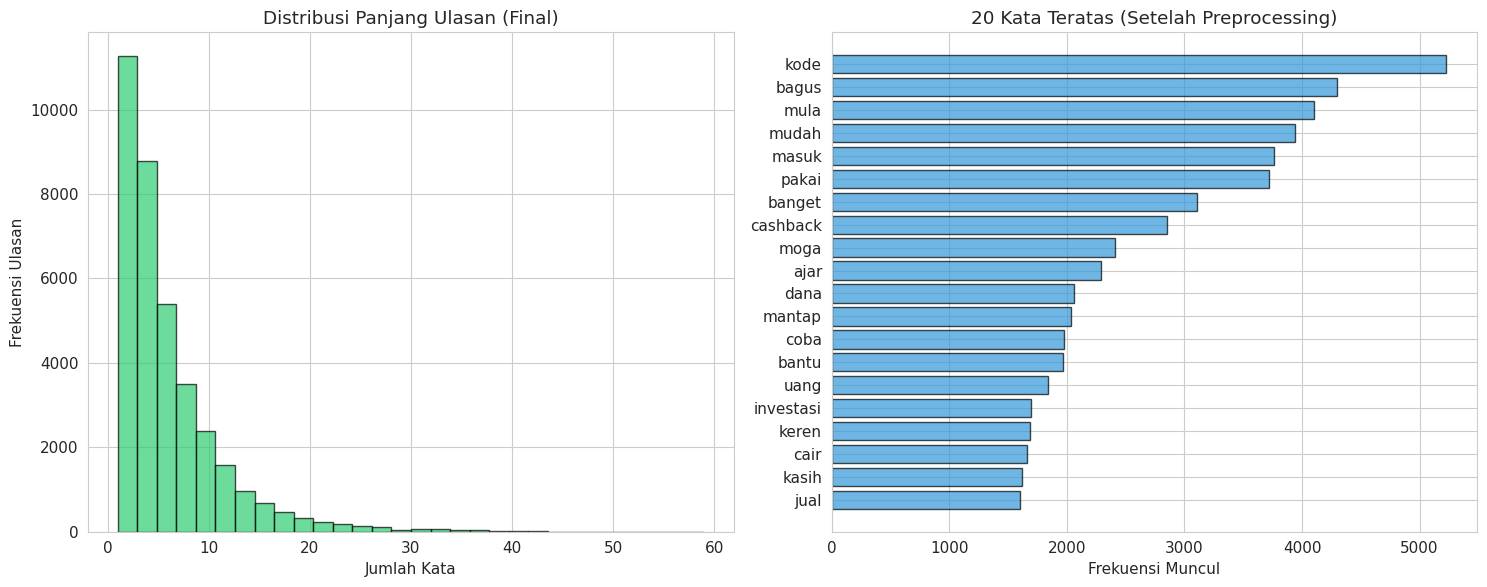

In [17]:
df_review['final_word_count'] = df_review['final_text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Distribusi panjang kata
axes[0].hist(df_review['final_word_count'], bins=30,
             color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Panjang Ulasan (Final)')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi Ulasan')

# Plot 2: 20 kata teratas
semua_kata_final = ' '.join(df_review['final_text']).split()
kata_top, hitung_top = zip(*Counter(semua_kata_final).most_common(20))

axes[1].barh(range(len(kata_top)), hitung_top,
             color='#3498db', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(kata_top)))
axes[1].set_yticklabels(kata_top)
axes[1].invert_yaxis()
axes[1].set_title('20 Kata Teratas (Setelah Preprocessing)')
axes[1].set_xlabel('Frekuensi Muncul')

plt.tight_layout()
plt.show()

### 12d. Tampilkan DataFrame Final

Menampilkan seluruh DataFrame untuk inspeksi akhir sebelum disimpan. Kolom yang tampil mencakup data asli, label sentimen, dan hasil setiap tahap preprocessing.

In [18]:
df_review

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sentiment,cleaned,tokens,token_count,tokens_no_sw,tokens_lemma,tokens_final,final_text,final_word_count
0,7e7dafb4-4bdb-47a5-a913-df0b6552231d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,KECEWA sudah nggk bisa pencairan instan (sesam...,1,0,3.107.0,2026-04-05 07:00:34,"Hai kak, terkait hal tersebut terdapat update ...",2026-04-05 20:38:22,3.107.0,negative,kecewa sudah enggak bisa pencairan instan sesa...,"[kecewa, sudah, enggak, bisa, pencairan, insta...",33,"[kecewa, pencairan, instan, bank, menunggu, tu...","[kecewa, cair, instan, bank, tunggu, tuju, ban...","[kecewa, cair, instan, bank, tunggu, tuju, ban...",kecewa cair instan bank tunggu tuju bank jatah...,18
1,71dbb877-abe4-4977-9321-aacbc2c9a2a1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bermanfaat buat menabung,5,0,3.107.0,2026-04-05 03:26:06,Terima kasih Kak Denny telah menjadi pengguna ...,2026-04-05 13:38:53,3.107.0,positive,sangat bermanfaat buat menabung,"[sangat, bermanfaat, buat, menabung]",4,"[bermanfaat, menabung]","[manfaat, tabung]","[manfaat, tabung]",manfaat tabung,2
2,0dcb19fc-efb7-4da7-83e3-0aa09927ff08,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya sangat suka dimana bibit menjadi aplikasi...,4,0,3.106.2,2026-04-04 22:06:56,"Hai Kak Rizky, kami mohon maaf atas ketidaknya...",2026-04-05 13:38:32,3.106.2,positive,saya sangat suka dimana bibit menjadi aplikasi...,"[saya, sangat, suka, dimana, bibit, menjadi, a...",34,"[suka, cocok, pemula, kasih, bintang, error, d...","[suka, cocok, mula, kasih, bintang, error, buk...","[suka, cocok, mula, kasih, bintang, error, buk...",suka cocok mula kasih bintang error buka bantu...,9
3,80812a23-73e0-4633-811f-bdcba99a0db3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa sekarang jatah Pencairan instan dibatas...,2,0,3.106.2,2026-04-04 13:47:36,Hai Kak Henry. Saat ini terdapat perubahan S &...,2026-04-05 13:36:37,3.106.2,negative,kenapa sekarang jatah pencairan instan dibatas...,"[kenapa, sekarang, jatah, pencairan, instan, d...",13,"[jatah, pencairan, instan, dibatasi, pencairan...","[jatah, cair, instan, batas, cair, instan, puas]","[jatah, cair, instan, batas, cair, instan, puas]",jatah cair instan batas cair instan puas,7
4,e9545ada-5741-4afb-b846-6c3c52aba31b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Gajelas, penambahn rekening baru gua ditolak, ...",1,0,3.107.0,2026-04-04 13:10:08,"Hai Kak Rapli, ketika tambah rekening, pastika...",2026-04-05 13:28:42,3.107.0,negative,gajelas penambahn rekening baru gua ditolak su...,"[gajelas, penambahn, rekening, baru, gua, dito...",11,"[gajelas, penambahn, rekening, gua, ditolak, s...","[gajelas, penambahn, rekening, gua, tolak, sal...","[gajelas, rekening, gua, tolak, saldo, gua, ny...",gajelas rekening gua tolak saldo gua nyangkut,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36272,58bfd2e7-33e9-40f1-86eb-7e44ba274067,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Investasi di level resiko yang gue nyaman. Tan...,5,2,1.1.0,2019-01-11 10:06:56,NaN,NaN,1.1.0,positive,investasi di level resiko yang gue nyaman tanp...,"[investasi, di, level, resiko, yang, gue, nyam...",10,"[level, resiko, gue, nyaman, janji, mulukmuluk]","[level, resiko, gue, nyaman, janji, mulukmuluk]","[level, resiko, gue, nyaman, janji]",level resiko gue nyaman janji,5
36273,0dc6339f-abba-43d9-afe5-746de3ddc4db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"bgus nih aplikasi ,jdi lebih mudah pilih sama ...",5,2,NaN,2019-01-11 10:00:42,NaN,NaN,NaN,positive,bagus nih aplikasi jdi lebih mudah pilih sama ...,"[bagus, nih, aplikasi, jdi, lebih, mudah, pili...",10,"[bagus, jdi, mudah, pilih, beli, rekasadana]","[bagus, jdi, mudah, pilih, beli, rekasadana]","[bagus, mudah, pilih, beli, rekasadana]",bagus 

### 12e. Ekspor ke CSV

Dataset yang telah bersih disimpan ke file `bibit_reviews_cleaned.csv`. Hanya kolom-kolom yang relevan untuk analisis lanjutan yang diikutsertakan: teks asli, skor, tanggal, jumlah likes, balasan, label sentimen, teks final, dan token final.

In [19]:
cols_to_save = [
    'content', 'score', 'at', 'thumbsUpCount',
    'replyContent', 'sentiment', 'final_text', 'tokens_final'
]

available_cols = [col for col in cols_to_save if col in df_review.columns]
df_clean       = df_review[available_cols].copy()

df_clean.to_csv('bibit_reviews_cleaned.csv', index=False)

print(f'✅ File disimpan : bibit_reviews_cleaned.csv')
print(f'   Shape        : {df_clean.shape[0]:,} baris x {df_clean.shape[1]} kolom')
df_clean.head(5)

✅ File disimpan : bibit_reviews_cleaned.csv
   Shape        : 36,277 baris x 8 kolom


,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_final
0,KECEWA sudah nggk bisa pencairan instan (sesam...,1,2026-04-05 07:00:34,0,"Hai kak, terkait hal tersebut terdapat update ...",negative,kecewa cair instan bank tunggu tuju bank jatah...,"[kecewa, cair, instan, bank, tunggu, tuju, ban..."
1,sangat bermanfaat buat menabung,5,2026-04-05 03:26:06,0,Terima kasih Kak Denny telah menjadi pengguna ...,positive,manfaat tabung,"[manfaat, tabung]"
2,saya sangat suka dimana bibit menjadi aplikasi...,4,2026-04-04 22:06:56,0,"Hai Kak Rizky, kami mohon maaf atas ketidaknya...",positive,suka cocok mula kasih bintang error buka bantu...,"[suka, cocok, mula, kasih, bintang, error, buk..."
3,kenapa sekarang jatah Pencairan instan dibatas...,2,2026-04-04 13:47:36,0,Hai Kak Henry. Saat ini terdapat perubahan S &...,negative,jatah cair instan batas cair instan puas,"[jatah, cair, instan, batas, cair, instan, puas]"
4,"Gajelas, penambahn rekening baru gua ditolak, ...",1,2026-04-04 13:10:08,0,"Hai Kak Rapli, ketika tambah rekening, pastika...",negative,gajelas rekening gua tolak saldo gua nyangkut,"[gajelas, rekening, gua, tolak, saldo, gua, ny..."
